In [2]:
# Imports
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from torchvision.models import resnet50
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import MeanShift, estimate_bandwidth
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

In [3]:
# Function
def preprocess_frame(frame):
        preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
                             ])
        return preprocess(frame)

In [4]:
# Model
num_classes = 1081
resnet_checkpoint_path = 'models/resnet50_weights_best_acc.tar'

model = resnet50(num_classes=num_classes)
checkpoint = torch.load(resnet_checkpoint_path, map_location='cpu')
state_dict = checkpoint["model"]

model = resnet50(num_classes=num_classes)
model.load_state_dict(state_dict=state_dict, strict=True)
model = torch.nn.Sequential(*(list(model.children())[:-1]))
model.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [5]:
# Datasets
dataset_1 = "data/frames/biodiverse/"
frames_1 = os.listdir(dataset_1)

dataset_2 = "data/frames/flower/"
frames_2 = os.listdir(dataset_2)

dataset_3 = "data/frames/biodiverse_a/"
frames_3 = os.listdir(dataset_3)

dataset_4 = "data/frames/grass_long/"
frames_4 = os.listdir(dataset_4)

dataset_5 = "data/frames/grass/"
frames_5 = os.listdir(dataset_5)

dataset_6 = "data/frames/grass_a/"
frames_6 = os.listdir(dataset_6)

In [6]:
dataset = dataset_4
frames = frames_4

print(1)

# Embeddings
embeddings = []
for frame in frames:
    img = Image.open(dataset + frame)
    preprocessed_img = preprocess_frame(img)
    input_tensor = preprocessed_img.unsqueeze(0)
    with torch.no_grad():
        features = model(input_tensor)
    embeddings.append(features.cpu().numpy().flatten())

embeddingspace = np.array(embeddings)

# Euclidean distance
centre = embeddingspace.mean(axis=0)
euclidean_distances = np.linalg.norm(embeddingspace - centre, axis=1)
threshold_eucl_rms = np.sqrt((euclidean_distances**2).mean())
threshold_eucl_med = np.median(euclidean_distances)

print("Euclidean distance RMS: ", threshold_eucl_rms)
print("Euclidean distance median: ", threshold_eucl_med)

# kNN density
k1 = 10
k2 = 25
k3 = 50

nbrs = NearestNeighbors(n_neighbors=k1+1, algorithm='auto', metric='cosine').fit(embeddingspace)
distances, indices = nbrs.kneighbors(embeddingspace)
distances = distances[:, 1:] # remove distance to self
density = 1 / (np.mean(distances, axis=1) + 1e-10)
average_density1 = np.mean(density)

nbrs = NearestNeighbors(n_neighbors=k2+1, algorithm='auto', metric='cosine').fit(embeddingspace)
distances, indices = nbrs.kneighbors(embeddingspace)
distances = distances[:, 1:] # remove distance to self
density = 1 / (np.mean(distances, axis=1) + 1e-10)
average_density2 = np.mean(density)

nbrs = NearestNeighbors(n_neighbors=k3+1, algorithm='auto', metric='cosine').fit(embeddingspace)
distances, indices = nbrs.kneighbors(embeddingspace)
distances = distances[:, 1:] # remove distance to self
density = 1 / (np.mean(distances, axis=1) + 1e-10)
average_density3 = np.mean(density)

print("Average kNN density 10 neighbors: ", average_density1)
print("Average kNN density 25 neighbors: ", average_density2)
print("Average kNN density 50 neighbors: ", average_density3)

# Global distance with pairwise distance
distances = pairwise_distances(embeddingspace, metric='cosine')
upper_distances = distances[np.triu_indices_from(distances, k=1)]
mean_distance = upper_distances.mean()
global_mean_density = 1 / (mean_distance + 1e-12)

median_distance = np.median(upper_distances)
global_median_density = 1 / (median_distance + 1e-12)

above_median_distances = upper_distances[upper_distances < median_distance]
above_median_median = np.median(above_median_distances)
above_median_density = 1 / (above_median_median + 1e-12)

print("Global mean density with pairwise distance: ", global_mean_density)
print("Global median density with pairwise distance: ", global_median_density)
print("Above median global density: ", above_median_density)

1
Euclidean distance RMS:  9.1399145
Euclidean distance median:  8.779057
Average kNN density 10 neighbors:  14.520973
Average kNN density 25 neighbors:  11.521014
Average kNN density 50 neighbors:  9.3074
Global mean density with pairwise distance:  5.4637677513079215
Global median density with pairwise distance:  5.84005277105736
Above median global density:  7.966922761621902


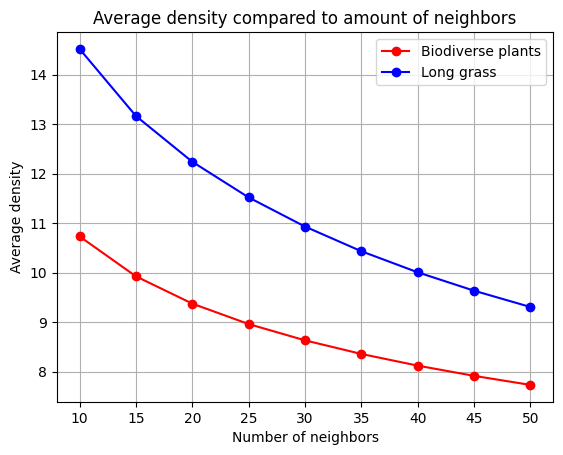

In [7]:
# Density calculation
k_val = [10, 15, 20, 25, 30, 35, 40, 45, 50]

embeddings = []
for frame in frames_1:
    img = Image.open(dataset_1 + frame)
    preprocessed_img = preprocess_frame(img)
    input_tensor = preprocessed_img.unsqueeze(0)
    with torch.no_grad():
        features = model(input_tensor)
    embeddings.append(features.cpu().numpy().flatten())

embeddingspace1 = np.array(embeddings)

embeddings = []
for frame in frames_4:
    img = Image.open(dataset_4 + frame)
    preprocessed_img = preprocess_frame(img)
    input_tensor = preprocessed_img.unsqueeze(0)
    with torch.no_grad():
        features = model(input_tensor)
    embeddings.append(features.cpu().numpy().flatten())

embeddingspace2 = np.array(embeddings)

all_densities1 = []
for k in k_val:
    nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='auto', metric='cosine').fit(embeddingspace1)
    distances, indices = nbrs.kneighbors(embeddingspace1)
    distances = distances[:, 1:] # remove distance to self
    density = 1 / (np.mean(distances, axis=1) + 1e-10)
    average_density = np.mean(density)
    all_densities1.append(average_density)

all_densities2 = []
for k in k_val:
    nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='auto', metric='cosine').fit(embeddingspace2)
    distances, indices = nbrs.kneighbors(embeddingspace2)
    distances = distances[:, 1:] # remove distance to self
    density = 1 / (np.mean(distances, axis=1) + 1e-10)
    average_density = np.mean(density)
    all_densities2.append(average_density)

plt.plot(k_val, all_densities1, marker='o', color='red', label="Biodiverse plants")
plt.plot(k_val, all_densities2, marker='o', color='blue', label="Long grass")
plt.xlabel("Number of neighbors")
plt.ylabel("Average density")
plt.title("Average density compared to amount of neighbors")
plt.grid(True)
plt.legend()
plt.show()

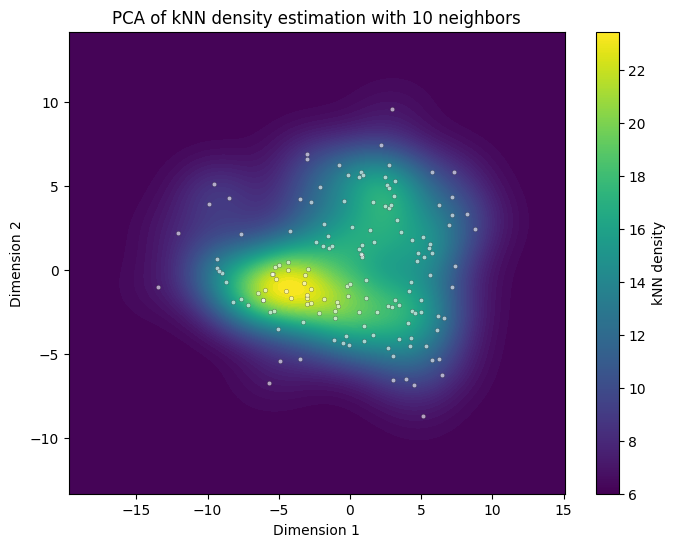

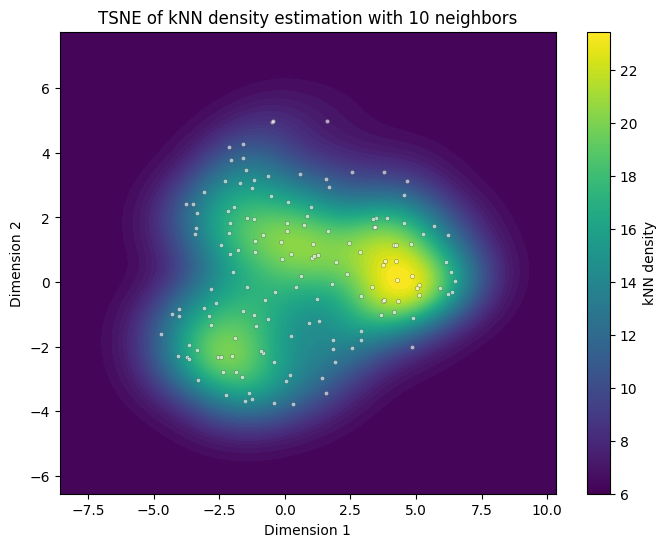

In [8]:
# Visualisation
import seaborn as sns
import matplotlib as mpl

# Reduce embeddings to 2D
pca = PCA(n_components=2, random_state=0)
pca_results = pca.fit_transform(embeddingspace)

tsne = TSNE(n_components=2, perplexity=50, random_state=0)
tsne_results = tsne.fit_transform(embeddingspace)

k1 = 10
k2 = 25
k3 = 50

nbrs = NearestNeighbors(n_neighbors=k1+1, algorithm='auto', metric='cosine').fit(embeddingspace)
distances, indices = nbrs.kneighbors(embeddingspace)
distances = distances[:, 1:] # remove distance to self
density = 1 / (np.mean(distances, axis=1) + 1e-10)
average_density1 = np.mean(density)

# Create seaborn heatmap using kdeplot
plt.figure(figsize=(8,6))
ax = sns.kdeplot(
    x=pca_results[:,0], y=pca_results[:,1],
    weights=density,  # weight by kNN density
    fill=True, cmap="viridis", levels=100, thresh=0
)

# Add colorbar for density
norm = mpl.colors.Normalize(vmin=min(density), vmax=max(density))
sm = mpl.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])  # dummy for colorbar
cbar = plt.colorbar(sm, ax=ax, label="kNN density")

sns.scatterplot(x=pca_results[:,0], y=pca_results[:,1], s=10, color="white", edgecolor="k", alpha=0.6)
plt.title("PCA of kNN density estimation with 10 neighbors")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

# Create seaborn heatmap using kdeplot
plt.figure(figsize=(8,6))
ax = sns.kdeplot(
    x=tsne_results[:,0], y=tsne_results[:,1],
    weights=density,  # weight by kNN density
    fill=True, cmap="viridis", levels=100, thresh=0
)

# Add colorbar for density
norm = mpl.colors.Normalize(vmin=min(density), vmax=max(density))
sm = mpl.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])  # dummy for colorbar
cbar = plt.colorbar(sm, ax=ax, label="kNN density")

sns.scatterplot(x=tsne_results[:,0], y=tsne_results[:,1], s=10, color="white", edgecolor="k", alpha=0.6)
plt.title("TSNE of kNN density estimation with 10 neighbors")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()


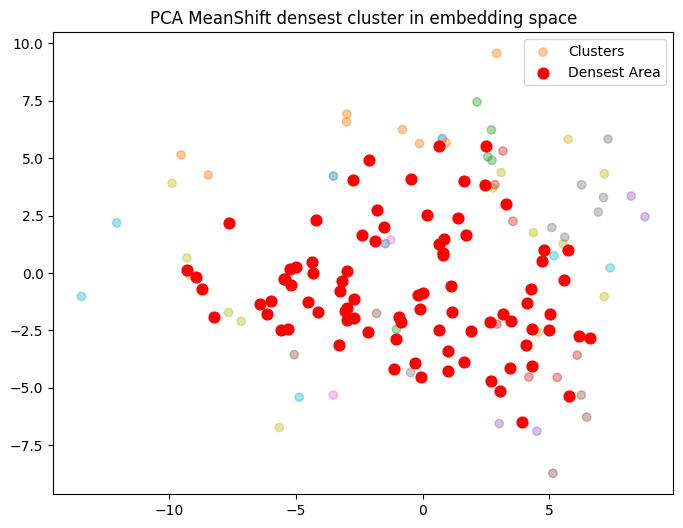

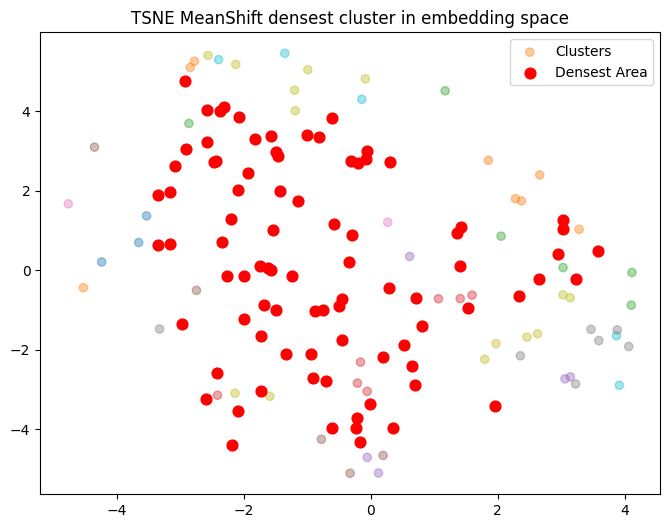

In [9]:
# MeanShift visualisation
# bandwidth = estimate_bandwidth(embeddingspace, quantile=0.2, n_samples=100)
bandwidth = 8
meanshift = MeanShift(bandwidth=bandwidth, bin_seeding=False)
meanshift.fit(embeddingspace)

labels = meanshift.labels_
cluster_centers = meanshift.cluster_centers_

# Find densest cluster
unique_labels, counts = np.unique(labels, return_counts=True)
densest_cluster_label = unique_labels[np.argmax(counts)]
dense_indices = np.where(labels == densest_cluster_label)[0]

pca = PCA(n_components=2, random_state=42)
reduced_embedding = pca.fit_transform(embeddingspace)

# Visualize densest area
plt.figure(figsize=(8, 6))
plt.scatter(reduced_embedding[:, 0], reduced_embedding[:, 1], c=labels, cmap='tab10', alpha=0.4, label='Clusters')
plt.scatter(reduced_embedding[dense_indices, 0], reduced_embedding[dense_indices, 1], color='red', label='Densest Area', s=60)
plt.title("PCA MeanShift densest cluster in embedding space")
plt.legend()
plt.show()

tsne = TSNE(n_components=2, perplexity=50, random_state=42)
reduced_embedding = tsne.fit_transform(embeddingspace)

# Visualize densest area
plt.figure(figsize=(8, 6))
plt.scatter(reduced_embedding[:, 0], reduced_embedding[:, 1], c=labels, cmap='tab10', alpha=0.4, label='Clusters')
plt.scatter(reduced_embedding[dense_indices, 0], reduced_embedding[dense_indices, 1], color='red', label='Densest Area', s=60)
plt.title("TSNE MeanShift densest cluster in embedding space")
plt.legend()
plt.show()